In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import seaborn as sns

In [2]:
df = pd.read_csv("./data/penguins_size.csv")
df.head(5)

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE


In [3]:
df.shape

(344, 7)

In [4]:
df.describe()

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g
count,342.000000,342.000000,342.000000,342.000000
mean,43.921930,17.151170,200.915205,4201.754386
std,5.459584,1.974793,14.061714,801.954536
min,32.100000,13.100000,172.000000,2700.000000
25%,39.225000,15.600000,190.000000,3550.000000
50%,44.450000,17.300000,197.000000,4050.000000
75%,48.500000,18.700000,213.000000,4750.000000
max,59.600000,21.500000,231.000000,6300.000000


In [5]:
a = df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   culmen_length_mm   342 non-null    float64
 3   culmen_depth_mm    342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                334 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


In [6]:
# Global variables to the notebook

categorical_col = ['species', 'island', 'sex']
numerical_col = ['culmen_length_mm', 'culmen_depth_mm', 'flipper_length_mm', 'body_mass_g']
palette = ["#EF476F", "#FFD166", "#06D6A0", "#118AB2", "#073B4C"]
# palette = https://coolors.co/palette/ef476f-ffd166-06d6a0-118ab2-073b4c

# Checking for NaN and null values

In [7]:
df.isna().sum()

species               0
island                0
culmen_length_mm      2
culmen_depth_mm       2
flipper_length_mm     2
body_mass_g           2
sex                  10
dtype: int64

In [8]:
df[df["culmen_depth_mm"].isna()].head(5)

# Two penguins have NaN values for all numeric (and sex) variables, I will choose to remove them.
# The rest are true, but

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN


In [9]:
df.dropna(inplace=True)
df.isna().sum()


species              0
island               0
culmen_length_mm     0
culmen_depth_mm      0
flipper_length_mm    0
body_mass_g          0
sex                  0
dtype: int64

In [10]:
df[df['sex'].isna()]

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex


In [11]:
print(df[~df["sex"].isin(["FEMALE", "MALE"])])

# There is one value of "." to the sex column.
# It also need to be removed

df.drop(df[df['sex'] == '.'].index, inplace=True)

    species  island  culmen_length_mm  culmen_depth_mm  flipper_length_mm  \
336  Gentoo  Biscoe              44.5             15.7              217.0   

     body_mass_g sex  
336       4875.0   .  


# Starting the analysis 

In [12]:
for col in categorical_col:
    print(df[col].value_counts())

species
Adelie       146
Gentoo       119
Chinstrap     68
Name: count, dtype: int64
island
Biscoe       163
Dream        123
Torgersen     47
Name: count, dtype: int64
sex
MALE      168
FEMALE    165
Name: count, dtype: int64


In [13]:
# Creating subsets to search the mean penguin of each island
## Biscoe Island:

biscoe_df = df[df['island'] == 'Biscoe']

for col in categorical_col:
    print(biscoe_df[col].value_counts())

biscoe_df.describe()

species
Gentoo    119
Adelie     44
Name: count, dtype: int64
island
Biscoe    163
Name: count, dtype: int64
sex
MALE      83
FEMALE    80
Name: count, dtype: int64


,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g
count,163.000000,163.000000,163.000000,163.000000
mean,45.248466,15.907362,209.558282,4719.171779
std,4.827319,1.827653,14.282467,790.860069
min,34.500000,13.100000,172.000000,2850.000000
25%,41.850000,14.500000,198.500000,4200.000000
50%,45.800000,15.600000,213.000000,4800.000000
75%,48.750000,17.000000,220.000000,5350.000000
max,59.600000,21.100000,231.000000,6300.000000


In [14]:
## Dream Island

dream_df = df[df['island'] == 'Dream']

for col in categorical_col:
    print(dream_df[col].value_counts())

dream_df.describe()

species
Chinstrap    68
Adelie       55
Name: count, dtype: int64
island
Dream    123
Name: count, dtype: int64
sex
MALE      62
FEMALE    61
Name: count, dtype: int64


,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g
count,123.000000,123.000000,123.000000,123.000000
mean,44.221951,18.339837,193.186992,3718.902439
std,5.947069,1.136629,7.428732,412.935581
min,32.100000,15.500000,178.000000,2700.000000
25%,39.200000,17.500000,188.000000,3412.500000
50%,45.200000,18.400000,193.000000,3700.000000
75%,49.900000,19.000000,198.000000,3962.500000
max,58.000000,21.200000,212.000000,4800.000000


In [15]:
## Torgersen Island

torgersen_df = df[df['island'] == 'Torgersen']

for col in categorical_col:
    print(torgersen_df[col].value_counts())

torgersen_df.describe()

species
Adelie    47
Name: count, dtype: int64
island
Torgersen    47
Name: count, dtype: int64
sex
FEMALE    24
MALE      23
Name: count, dtype: int64


,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g
count,47.000000,47.000000,47.000000,47.000000
mean,39.038298,18.451064,191.531915,3708.510638
std,3.028097,1.346472,6.220062,451.846351
min,33.500000,15.900000,176.000000,2900.000000
25%,36.650000,17.450000,187.500000,3337.500000
50%,39.000000,18.400000,191.000000,3700.000000
75%,41.100000,19.250000,195.500000,4000.000000
max,46.000000,21.500000,210.000000,4700.000000


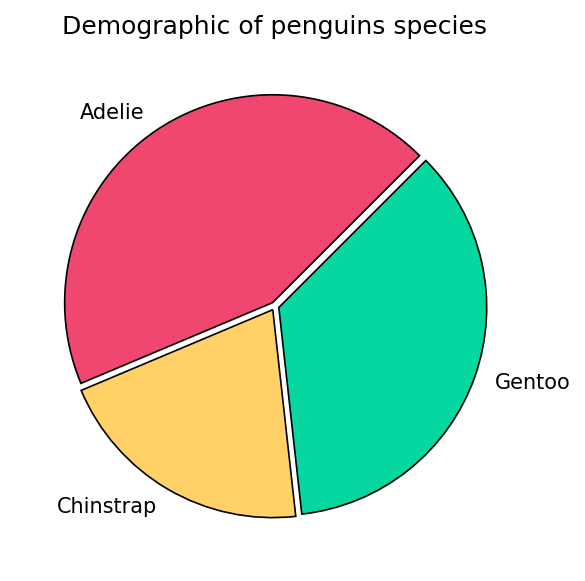

In [16]:
# Visualizing the data (categorical)
plt.figure(figsize=(8, 4.5), dpi=150)

species_counter = Counter(df["species"])
labels = list(species_counter.keys())
values = list(species_counter.values())

explode = [0.02, 0.02, 0.02]

plt.pie(values, 
        labels=labels, 
        colors=palette[0:len(labels)], 
        startangle=45, 
        explode=explode, 
        wedgeprops={"edgecolor": "black", "linewidth": 0.8})

plt.title("Demographic of penguins species")
plt.show()

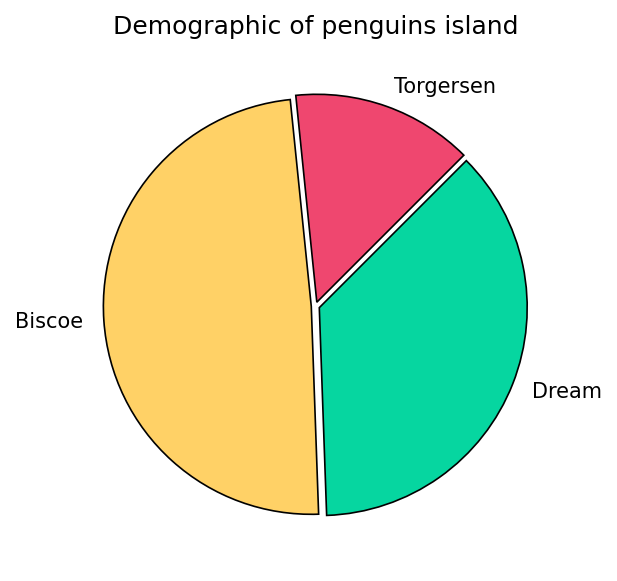

In [17]:
# Visualizing the data (categorical)
plt.figure(figsize=(8, 4.5), dpi=150)

island_counter = Counter(df["island"])
labels = list(island_counter.keys())
values = list(island_counter.values())

explode = [0.02, 0.02, 0.02]

plt.pie(values,
        labels=labels,
        colors=palette[0:len(labels)],
        startangle=45,
        explode=explode,
        wedgeprops={"edgecolor": "black", "linewidth": 0.8})

plt.title("Demographic of penguins island")
plt.show()

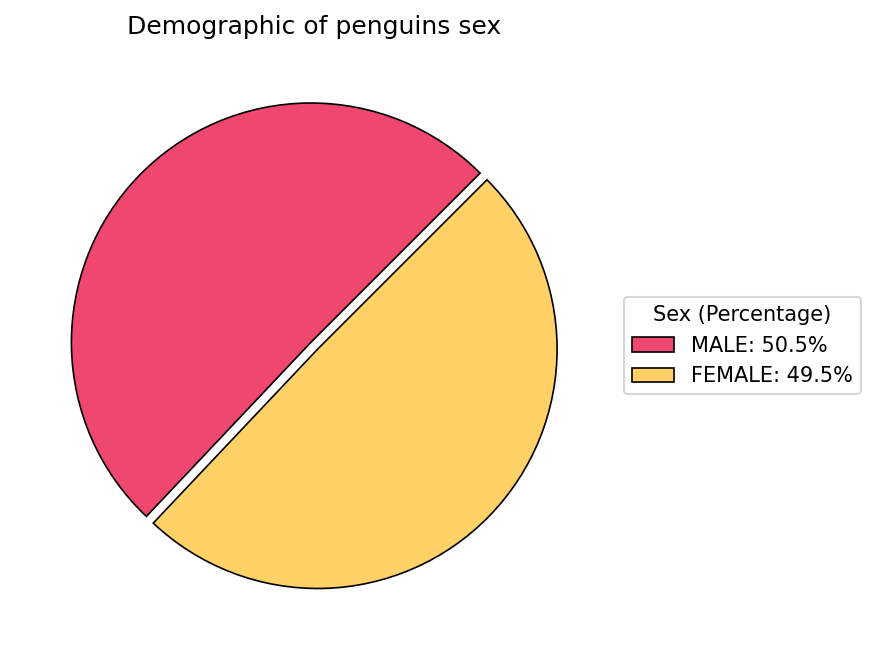

In [18]:
# Visualizing the data (categorical)
plt.figure(figsize=(8, 4.5), dpi=150)

sex_counter = Counter(df["sex"])
labels = list(sex_counter.keys())
values = list(sex_counter.values())

explode = [0.02] * len(values)

total = sum(values)
percentages = [f'{value/total*100:.1f}%' for value in values]

legend_labels = [f'{label}: {pct}' for label, pct in zip(labels, percentages)]

wedges, texts = plt.pie(values, 
                                labels=None, 
                                colors=palette[0:len(labels)], 
                                startangle=45, 
                                explode=explode, 
                                wedgeprops={"edgecolor": "black", "linewidth": 0.8})


plt.legend(wedges, legend_labels, 
           title="Sex (Percentage)", 
           loc="center left", 
           bbox_to_anchor=(1, 0, 0.5, 1))


plt.title("Demographic of penguins sex")
plt.tight_layout()
plt.show()

<Figure size 1200x675 with 0 Axes>

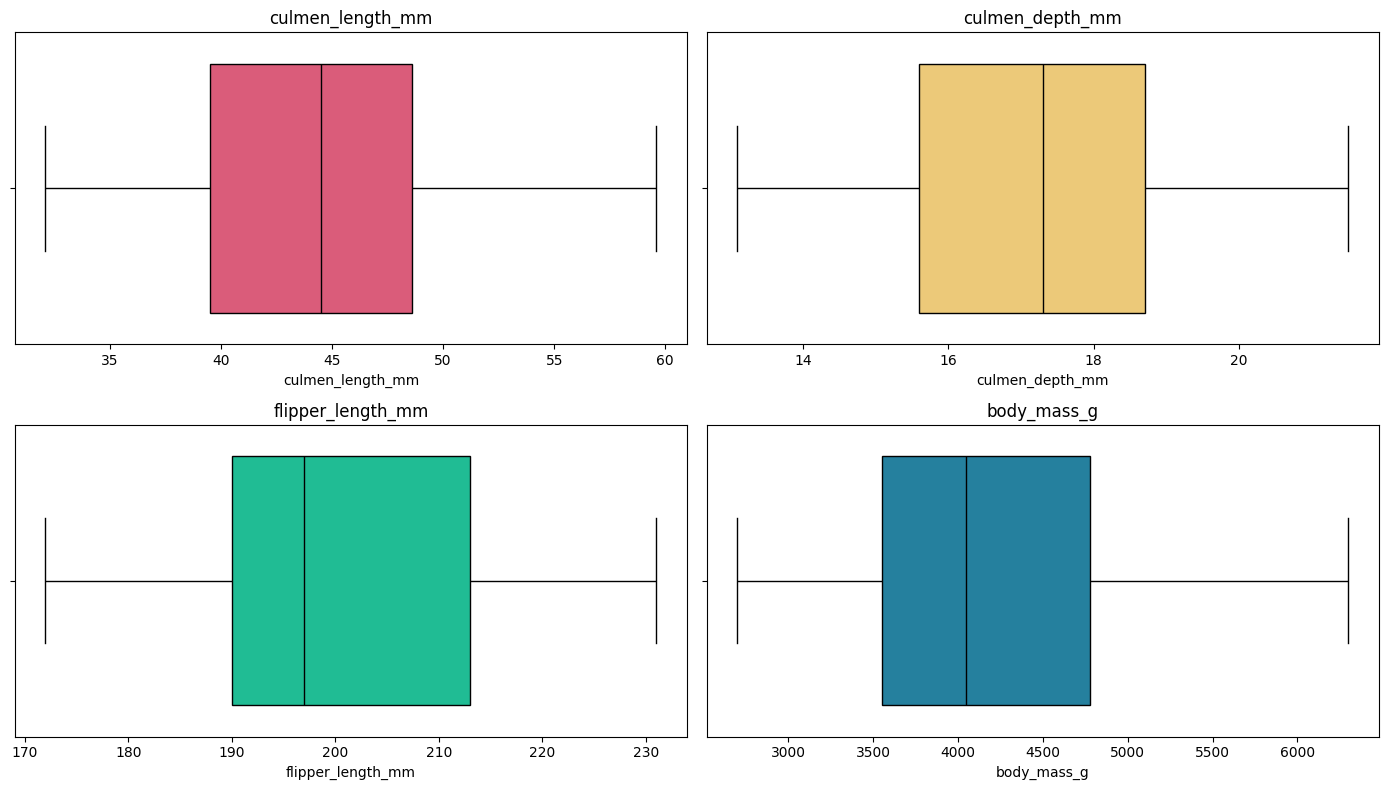

In [19]:
# Searching for numeric outliers:
# culmen_length_mm	culmen_depth_mm	flipper_length_mm	body_mass_g
plt.figure(figsize=(8, 4.5), dpi=150)

n_cols = len(numerical_col)
n_rows = (n_cols + 1) // 2 

fig, axes = plt.subplots(n_rows, 2, figsize=(14, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(numerical_col):
    sns.boxplot(x=df[col].dropna(), ax=axes[i], color=palette[i], linecolor="#000000")
    axes[i].set_title(col)

for j in range(n_cols, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

In [20]:
Q1 = df[col].quantile(0.25)
Q3 = df[col].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df[col] < lower) | (df[col] > upper)]
print(len(outliers))

0


# Checking for correlations

In [21]:

for penguin_species in df['species'].dropna().unique():
    df_species = df[df['species'] == penguin_species].copy()
    print(f'Penguin species:{penguin_species}')
    print(df_species[numerical_col].corr().round(4))
    print('--------------------------------------------')

Penguin species:Adelie
                   culmen_length_mm  culmen_depth_mm  flipper_length_mm  \
culmen_length_mm             1.0000           0.3858             0.3323   
culmen_depth_mm              0.3858           1.0000             0.3109   
flipper_length_mm            0.3323           0.3109             1.0000   
body_mass_g                  0.5443           0.5802             0.4649   

                   body_mass_g  
culmen_length_mm        0.5443  
culmen_depth_mm         0.5802  
flipper_length_mm       0.4649  
body_mass_g             1.0000  
--------------------------------------------
Penguin species:Chinstrap
                   culmen_length_mm  culmen_depth_mm  flipper_length_mm  \
culmen_length_mm             1.0000           0.6535             0.4716   
culmen_depth_mm              0.6535           1.0000             0.5801   
flipper_length_mm            0.4716           0.5801             1.0000   
body_mass_g                  0.5136           0.6045             

In [22]:
df.groupby("species")[
    ['culmen_length_mm', 'culmen_depth_mm', 'flipper_length_mm', 'body_mass_g']
].mean()

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g
species,,,,
Adelie,38.823973,18.347260,190.102740,3706.164384
Chinstrap,48.833824,18.420588,195.823529,3733.088235
Gentoo,47.568067,14.996639,217.235294,5092.436975


C:\Users\leona\AppData\Local\Temp\ipykernel_32980\3439330783.py:11: UserWarning: The palette list has more values (5) than needed (3), which may not be intended.
  sns.scatterplot(


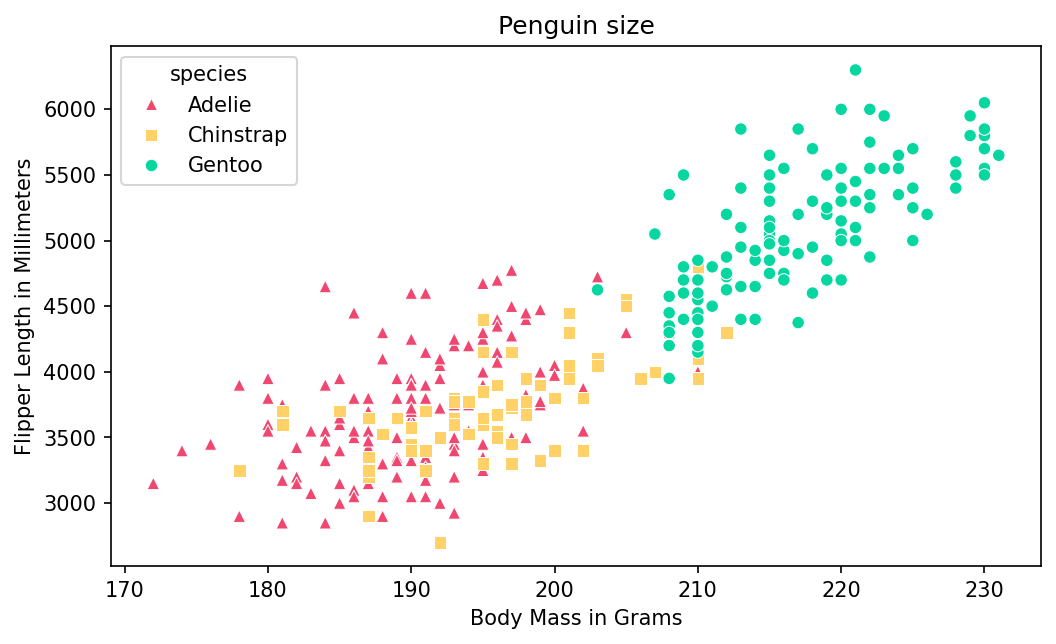

In [23]:
# Ploting a chart that displays penguins "size" grouping by penguins species

plt.figure(figsize=(8, 4.5), dpi=150)

markers = {
    "Adelie": "^",
    "Chinstrap": "s",
    "Gentoo": "o"
}

sns.scatterplot(
    data=df,
    y="body_mass_g",
    x="flipper_length_mm",
    hue="species",
    style="species",
    markers=markers,
    palette=palette
)

plt.title("Penguin size")
plt.xlabel("Body Mass in Grams")
plt.ylabel("Flipper Length in Millimeters")
plt.show()

C:\Users\leona\AppData\Local\Temp\ipykernel_32980\662952521.py:12: UserWarning: The palette list has more values (5) than needed (3), which may not be intended.
  sns.scatterplot(


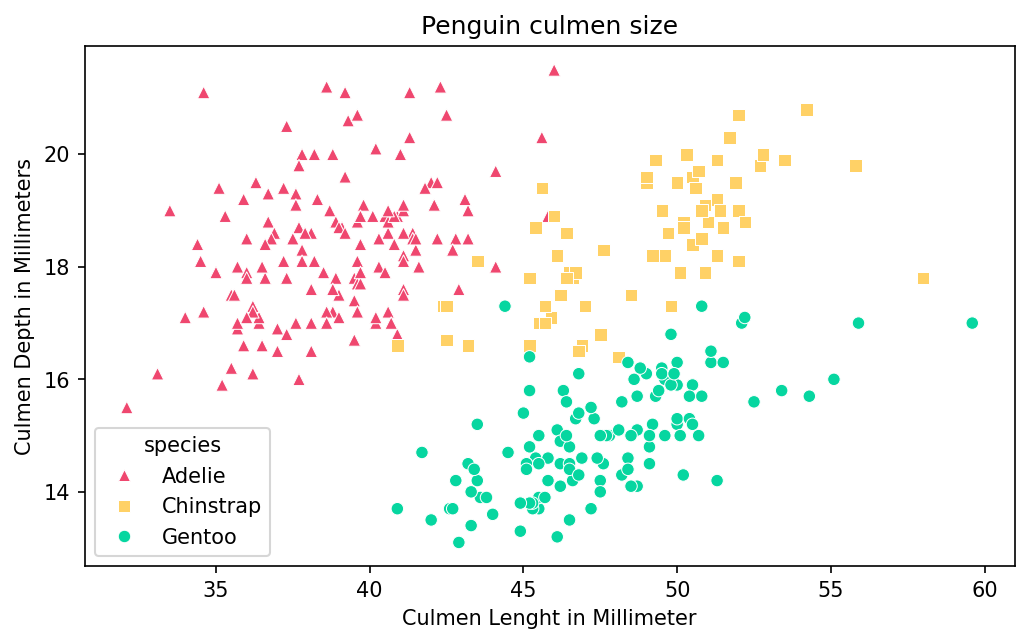

In [24]:
# Ploting a chart that displays penguins  "size" grouping by penguins species
# culmen_length_mm	culmen_depth_mm

plt.figure(figsize=(8, 4.5), dpi=150)

markers = {
    "Adelie": "^",
    "Chinstrap": "s",
    "Gentoo": "o"
}

sns.scatterplot(
    data=df,
    x="culmen_length_mm",
    y="culmen_depth_mm",
    hue="species",
    style="species",
    markers=markers,
    palette=palette
)

plt.title("Penguin culmen size")
plt.xlabel("Culmen Lenght in Millimeter")
plt.ylabel("Culmen Depth in Millimeters")
plt.show()

# INSIGHTS  

### Islands and Species  
Adelie penguins habits all three islands, but they are exclusive in torgersen island  
Biscoe Island is the main island for the Gentoo. Dream is the main island for the Chinstrap  
And Torgersen is the main island for the Adelie (Adelie is also the only species that appear in all 3 islands)  
Biscoe = Gentoo || Dream = Chinstrap || Torgersen = Adelie  

### Numerical values  
No possible outliers  
##### Gentoo  
Gentoo are massive in weight, having the biggest body mass. (137% of the mass of the other species)  
Gentoo have more sharp culmen and bigger flippers  
##### Adelie
Adelie penguins have less weight and smaller flippers  
Their culmen are the smallest among them all but their depht are a little bit above average  
##### Chinstrap  
Chinstrap are almost equal to the adelie species, but they have a bigger culmen (even bigger than the gentoo's ones)  
They also have a slighty bigger flipper comparing with the adelies, and a culmen of (aprox.) the same size  


In [25]:
#### INSIGHTS

### ! Islands and Species
# Adelie penguins habits all three islands, but they are exclusive in torgersen island
# Biscoe Island is the main island for the Gentoo. Dream is the main island for the Chinstrap
# And Torgersen is the main island for the Adelie (Adelie is also the only species that appear in all 3 islands)
# Biscoe = Gentoo || Dream = Chinstrap || Torgersen = Adelie

### ! Numerical values
# No possible outliers
## ? Gentoo
# Gentoo are massive in weight, having the biggest body mass. (137% of the mass of the other species)
# Gentoo have more sharp culmen and bigger flippers
## ? Adelie
# Adelie penguins have less weight and smaller flippers
# Their culmen are the smallest among them all but their depht are a little bit above average
## ? Chinstrap
# Chinstrap are almost equal to the adelie species, but they have a bigger culmen (even bigger than the gentoo's ones)
# They also have a slighty bigger flipper comparing with the adelies, and a culmen of (aprox.) the same size
